# Position XY scan — example

Loads a 2-D position (X/Y piezo) scan from `data/position-xy-scan/`: a laser-spot reference image, a white-light reference of the sample, and a 57-point grid of white-light images, real-space PL images, and PL spectra — one triplet per scan position.

Uses only functions already in the library: `tmdc.loaders.ACLaserRefImg`/`ACSampleImg` for the laser spot, `tmdc.loaders.ACSpectralSweep` (with its `sweep_grid()` auto-detection, `fast_sweep=`/`slow_sweep=` nest declaration, `cosmic_rays=`/`bg_region_eV=` corrections, and `as_grid()`/`as_image_grid()`) for the swept parameters, `tmdc.plotting.animate_wl_pl_spectra_grid` for the three-panel animation, `tmdc.plotting.plot_spectra_overlay`/`plot_multi_voigt_overlay` and `tmdc.fitting.fit_pl_peaks`/`find_extra_peaks` for the overlay and fit sections below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML

import leman as tmdc
from leman import constants, fitting, plotting, processing

POSITION_XY_DIR = "./data/position-xy-scan"

# The default 20 MB embed limit truncates a 57-frame, 3-panel HTML5 animation
# partway through -- raised here so every frame is actually scrubbable below,
# rather than silently dropping the tail of the animation.
plt.rcParams["animation.embed_limit"] = 100

## Locating the laser spot

`ACLaserRefImg` fits the spot's centre and 1/e² radius from a dedicated laser-spot image, the same pipeline used in the other position-scan examples. `show_image(laser_annotation=True)` draws that fitted boundary directly on the image it was fitted from.

ACLaserRefImg
  File                  : ./data/position-xy-scan/laser_pos_26_06_30_17_00_50.csv
  Center                : (271.6, 217.7) px
  Estimated 1/e² Radius : 4.7 px
  Estimated 1/e² Diameter: 9.5 px


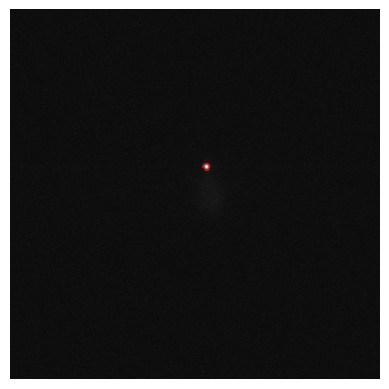

In [2]:
laser = tmdc.loaders.ACLaserRefImg(
    f"{POSITION_XY_DIR}/laser_pos_26_06_30_17_00_50.csv", expected_radius_px=10,
)
fig, ax = laser.show_image(laser_annotation=True)
print(laser)

## Laser spot on the white-light image

`ACSampleImg` takes the same `laser_ref`, so the boundary drawn here is the identical fit from above — not a second detection on this image.

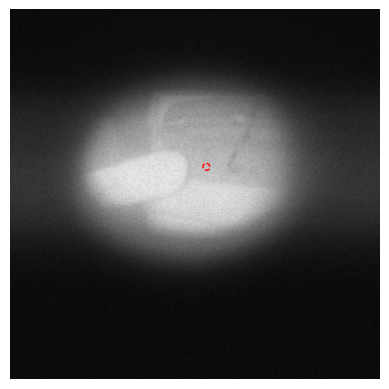

In [3]:
sample_image = tmdc.loaders.ACSampleImg(
    f"{POSITION_XY_DIR}/wl_26_06_30_17_00_23.csv", laser_ref=laser,
)
fig, ax = sample_image.show_image(laser_annotation=True)

## Loading the scan and identifying the swept parameters

The scan is a single spectral-sweep file holding one column-block per position, plus separate white-light and real-space-PL image sequences (one file per position, in `wl/` and `pl/`). Which two parameters were actually scanned is not assumed here: `ACSpectralSweep.sweep_grid()` detects a 2-D raster directly from the parameter rows (two varying rows whose distinct-value counts multiply out to the sweep length) — a stronger signature than `varying_parameters()`'s full evidence dump (also shown below, via `print(scan)`), where a leakage current or a static gate's read-back jitter can *also* register as "varying" without being the swept axis.

In [4]:
SPECTRAL_PATH = f"{POSITION_XY_DIR}/pl/pl_26_06_30_16_29_41_iter_0.csv"

scan_probe = tmdc.loaders.ACSpectralSweep(SPECTRAL_PATH, spectra_type="PL")
print(scan_probe)

grid = scan_probe.sweep_grid()
if grid is None:
    raise RuntimeError("sweep_grid() found no 2-D raster in this file -- check the data.")
print(f"\nAuto-detected raster: {grid}")

# bg_region_eV=(1.72, 1.75): this window sits above every PL feature in
# constants.PL_PEAKS["WSe2"] and is flat to within 1 count across all 57
# sweeps (mean 612.9-613.7, checked against scan_probe.best_energy_spectra
# before committing to it) -- a genuine signal-free pedestal, not merely the
# lowest-signal window. subtract_background takes its mean as a scalar
# constant removed from every spectrum, in wavelength space before the
# Jacobian (see CLAUDE.md's "Background comes off both arrays before the
# ratio"). Declared using the labels sweep_grid() itself reported -- not
# hardcoded -- so this scan carries a proper nest (scan.nesting, as_grid())
# instead of only a flat sweep index. cosmic_rays={} repairs cosmic-ray
# pixels (defaults to processing.remove_cosmic_rays's own sigma_threshold/
# median_window/max_iter) in the wavelength-space chain, before
# energy_spectra / best_energy_spectra are built -- every consumer below
# (get_spectrum_at, plot_spectrum, as_grid, the animation's
# NormalizedSpectrumPanel) reads best_energy_spectra, so these two
# declarations are what keep a cosmic ray and a constant pedestal out of
# everything shown from here on.
scan = tmdc.loaders.ACSpectralSweep(
    SPECTRAL_PATH, spectra_type="PL",
    fast_sweep=grid.fast_label, slow_sweep=grid.slow_label,
    cosmic_rays={}, bg_region_eV=(1.72, 1.75),
)
print(f"\nDeclared as a nest: {scan.nesting}")
if scan.cosmic_ray_mask is not None:
    print(f"Cosmic-ray pixels repaired: {int(scan.cosmic_ray_mask.sum())} "
          f"across {scan.n_sweeps} sweeps")
if scan.bg_region_nm is not None:
    print(f"Background region: {scan.bg_region_nm[0]:.1f} - {scan.bg_region_nm[1]:.1f} nm")

ACSpectralSweep — 57 sweeps × 1340 pixels  [Photoluminescence]
  File        : ./data/position-xy-scan/pl/pl_26_06_30_16_29_41_iter_0.csv
  λ range     : 707.3 – 831.4 nm
  Energy range: 1.491 – 1.753 eV
  Sweep       : not declared — sweep index used as the axis
  Gates       : dual-gate, independent  — wiring not declared; pass gates={'top': ..., 'bottom': ...} for v_top/v_bot/E_F
  Power       : 41.3 → 41.7 µW
  Varying     : I_B, Scanner X, Scanner Y, V_A
  Grid        : Scanner X (19) × Scanner Y (3) = 57  — detected, not declared; pass fast_sweep='Scanner X', slow_sweep='Scanner Y'
  Blocks      : 114 declared, 57 zero-filled and dropped
  ROI         : ExpROI1
  Jacobian    : not applied


Auto-detected raster: Scanner X (19) × Scanner Y (3) = 57

Declared as a nest: Scanner X (19, fast) × Scanner Y (3, slow) = 57
Cosmic-ray pixels repaired: 318 across 57 sweeps
Background region: 708.5 - 720.8 nm


## Loading the image sequences

Each is one file per scan position, sharing the same `laser_ref` so the fitted circle overlays both. The AttoCube acquisition can leave one extra white-light frame at the end relative to the declared sweep — confirmed once, by comparing the two possible trims as full three-panel animations (an off-by-one there shows up as the white-light view visibly lagging the real-space-PL spot, which a single-frame comparison cannot reveal). Resolved the same way every time it happens: whenever the frame count disagrees, `plotting.TrimmedImageSequence` keeps only the first `scan.n_sweeps` frames, dropping the rest from the end.

In [5]:
wl_scan = tmdc.loaders.ACImgSweep(
    f"{POSITION_XY_DIR}/wl/", prefix="wl_iter_", laser_ref=laser,
)
pl_scan = tmdc.loaders.ACImgSweep(
    f"{POSITION_XY_DIR}/pl/", prefix="pl_iter_", laser_ref=laser,
)

# plotting.trim_to_sweep_count warns (rather than prints) when it drops
# frames -- the same known AttoCube quirk animate_wl_pl_spectra_grid's own
# auto_trim= handles internally, done here once up front so the grid-shape
# check below and the animation later see the identical, already-trimmed wl.
wl = plotting.trim_to_sweep_count(wl_scan, scan.n_sweeps)

print(f"White light   : {wl.n_frames} frames")
print(f"Real-space PL : {pl_scan.n_frames} frames")
print(f"Spectral sweep: {scan.n_sweeps} points")

White light   : 57 frames
Real-space PL : 57 frames
Spectral sweep: 57 points


C:\Users\Brandon\AppData\Local\Temp\ipykernel_27404\216514955.py:12: UserWarning: ACImgSweep has 58 frames vs 57 sweep points -- dropping 1 frame(s) from the end.
  wl = plotting.trim_to_sweep_count(wl_scan, scan.n_sweeps)


## Putting the data on the grid

`scan.as_grid()` reshapes the flat 57-point spectral sweep onto the declared `(n_slow, n_fast)` nest. The two image sequences get the identical check — do they actually carry one frame per declared sweep point? — via `scan.as_image_grid()`, which stacks an image sequence's frames and runs them through `as_grid()` the same way: any mismatch raises the exact error `as_grid()` already gives for the spectral array itself, not a second, differently-worded one written just for images.

In [6]:
spectra_grid = scan.as_grid(scan.best_energy_spectra)
print(f"Spectra grid shape       : {spectra_grid.shape}  (n_pixels, n_slow, n_fast)")

wl_grid = pl_grid = None
for name, image_scan in [("White light", wl), ("Real-space PL", pl_scan)]:
    try:
        image_grid = scan.as_image_grid(image_scan)
        print(f"{name} grid shape{' ' * (12 - len(name))}: {image_grid.shape}  "
              f"(height, width, n_slow, n_fast)")
    except ValueError as e:
        print(f"{name}: does NOT match the declared grid -- {e}")
        continue
    if name == "White light":
        wl_grid = image_grid
    else:
        pl_grid = image_grid

Spectra grid shape       : (1340, 3, 19)  (n_pixels, n_slow, n_fast)
White light grid shape : (512, 512, 3, 19)  (height, width, n_slow, n_fast)
Real-space PL grid shape: (512, 512, 3, 19)  (height, width, n_slow, n_fast)


## Three-panel animation, in a chosen traversal order

The sweep itself was written fast-axis-inner (every `Scanner X` position visited before `Scanner Y` steps once). `plotting.animate_wl_pl_spectra_grid` — the nested-sweep sibling of `plotting.animate_wl_pl_spectra`, promoted out of this notebook — plays the animation in any of the four axis-order/direction combinations directly from `scan`, `wl`, `pl_scan`, no grid-building or panel-assembly code needed here:

- `inner_axis="fast"` (default) or `"slow"` — which axis varies fastest. Leaving this at its default reproduces the order the data was written in.
- `reverse_fast`, `reverse_slow` — traverse that axis in decreasing order instead of increasing; the two combine independently of each other and of `inner_axis`, so all four reversal combinations are just these two booleans.

`wl` was already trimmed to `scan.n_sweeps` above, for the grid-shape check — `animate_wl_pl_spectra_grid` has the identical trim built in (`auto_trim=True` by default, warning instead of printing) for a caller who passes an image sequence straight from its loader.

Rendered inline as HTML5 (`anim.to_jshtml()`) so it can be scrubbed frame-by-frame rather than only played through once. Saving is commented out below; `.mp4` goes through FFmpeg rather than the default GIF/Pillow writer, avoiding the 256-colour palette quantization that can wash out the thin laser-circle overlay.

TypeError: slice indices must be integers or None or have an __index__ method

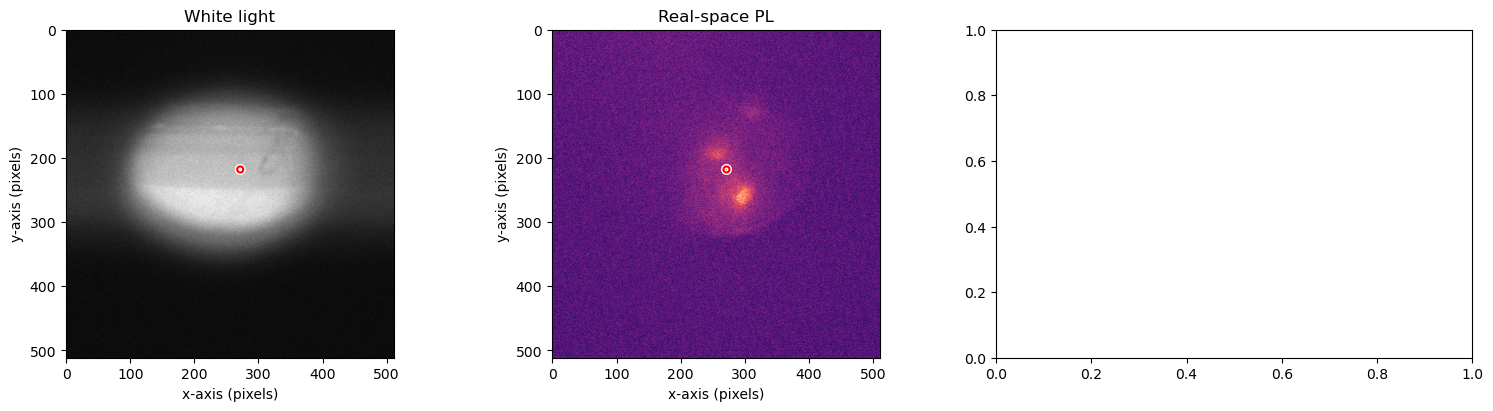

In [7]:
fig, anim = plotting.animate_wl_pl_spectra_grid(
    scan, wl=wl, pl=pl_scan, inner_axis="slow", interval_ms=200,
)

# anim.save("position_xy_scan.mp4")  # uncomment to save to disk

# Closed before display: to_jshtml() below embeds its own player, and the
# inline backend would otherwise also auto-display the bare figure as a
# second, static image alongside it.
# plt.close(fig)
# HTML(anim.to_jshtml())

## Overlaying spectra at chosen positions

Rather than scrubbing the animation above, a fixed set of `(Scanner X, Scanner Y)`
positions can be pulled out and compared directly: one panel with the (cosmic-ray-repaired,
background-subtracted, smoothed) spectra, one with each spectrum normalised to its own
`[0, 1]` range, so a weaker point is not visually dwarfed by a brighter one.
`plotting.plot_spectra_overlay` draws both panels from a `{label: spectrum}` dict — this
notebook only resolves each `(fast, slow)` coordinate to a spectrum via
`scan.get_spectrum_at`, everything else (the two-panel layout,
`processing.smooth_savgol`, `processing.normalise_minmax`, legends) is the library
function's job, not re-implemented here.

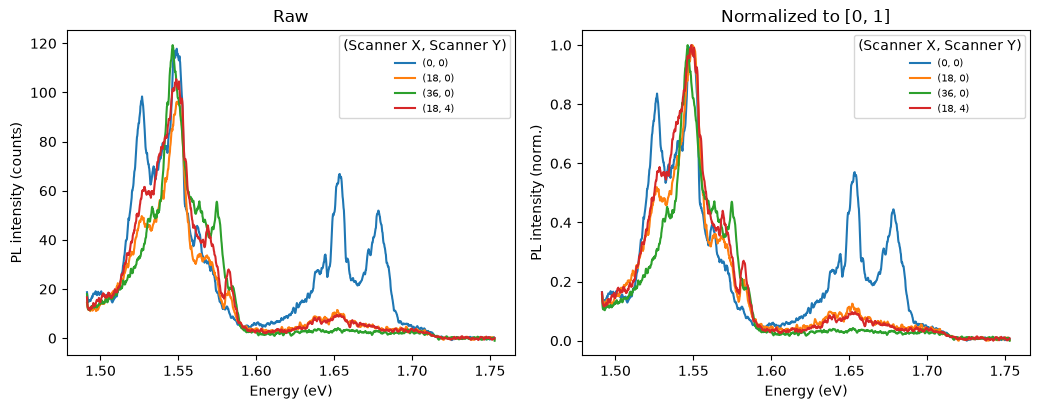

In [ ]:
SMOOTH_WINDOW, SMOOTH_POLY = 11, 3  # matches NormalizedSpectrumPanel's own defaults

# A few positions spanning the fast axis at the first and last slow-axis rows --
# taken from the nest's own coordinates, so this works on any raster rather than
# only this file's 19 x 3 grid.
fast_axis, slow_axis = scan.nesting.fast_axis, scan.nesting.slow_axis
points = [
    (fast_axis[0], slow_axis[0]),
    (fast_axis[len(fast_axis) // 2], slow_axis[0]),
    (fast_axis[-1], slow_axis[0]),
    (fast_axis[len(fast_axis) // 2], slow_axis[-1]),
]

spectra = {
    f"({fast_val:.3g}, {slow_val:.3g})": scan.get_spectrum_at(fast=fast_val, slow=slow_val)
    for fast_val, slow_val in points
}

fig, (ax_raw, ax_norm) = plotting.plot_spectra_overlay(
    spectra, scan.energy, xlabel="Energy (eV)",
    ylabel=scan.signal_label, ylabel_normalized=f"{scan.signal_name} (norm.)",
    smooth_window=SMOOTH_WINDOW, smooth_poly=SMOOTH_POLY,
)
for ax in (ax_raw, ax_norm):
    ax.legend(fontsize=7, title=f"({scan.nesting.fast_label}, {scan.nesting.slow_label})")

## Fitting the PL peaks at the same positions

WSe₂ PL in this energy range generally carries three features (`constants.PL_PEAKS["WSe2"]`):
the intralayer neutral exciton **X0** (≈ 1.70 eV), its trion **XT** just below it, and one or
more unresolved interlayer hybrid **IX** features around 1.50–1.60 eV — plus, at some
positions, smaller features neither seed accounts for. All of it is fit in one pass per
spectrum, on the same cosmic-ray-repaired, background-subtracted, smoothed data plotted
above, with two library functions (no notebook-local fitting code):

1. `fitting.fit_pl_peaks(x, y, material="WSe2")` seeds and fits X0/XT/IX — same shape as
   `fitting.fit_raman_modes`, just reading `constants.PL_PEAKS` instead of
   `constants.RAMAN_MODES`.
2. `fitting.find_extra_peaks(x, y, base_result)` looks at what that fit leaves behind:
   repeatedly locates the largest residual peak away from every already-fitted center (the
   same mechanism `fit_raman_modes` uses once, via `fitting.locate_residual_peak`, for its
   unseeded shoulder mode — here looped rather than stopped at one), adds a Voigt there, and
   refits, until the largest remaining residual no longer clearly exceeds the noise floor.

One `fitting.fit_multi_voigt` result per position comes out the other end, drawn against the
data with a single `plotting.plot_multi_voigt_overlay` call — not two separate fits shown
side by side.

(0, 0): 3 additional peak(s) beyond X0/XT/IX
         X0: center=1.5408 eV  amp=73
         XT: center=1.6483 eV  amp=27
         IX: center=1.5250 eV  amp=43
     extra1: center=1.5492 eV  amp=57
     extra2: center=1.6532 eV  amp=39
     extra3: center=1.6786 eV  amp=45
(18, 0): 5 additional peak(s) beyond X0/XT/IX
         X0: center=1.6937 eV  amp=3
         XT: center=1.6500 eV  amp=8
         IX: center=1.5284 eV  amp=23
     extra1: center=1.5503 eV  amp=64
     extra2: center=1.5261 eV  amp=24
     extra3: center=1.5678 eV  amp=24
     extra4: center=1.5831 eV  amp=10
     extra5: center=1.5422 eV  amp=32
(36, 0): 1 additional peak(s) beyond X0/XT/IX
         X0: center=1.6776 eV  amp=1
         XT: center=1.6578 eV  amp=1
         IX: center=1.5468 eV  amp=100
     extra1: center=1.5735 eV  amp=27
(18, 4): 4 additional peak(s) beyond X0/XT/IX
         X0: center=1.6947 eV  amp=3
         XT: center=1.6518 eV  amp=7
         IX: center=1.5307 eV  amp=55
     extra1: center=1.54

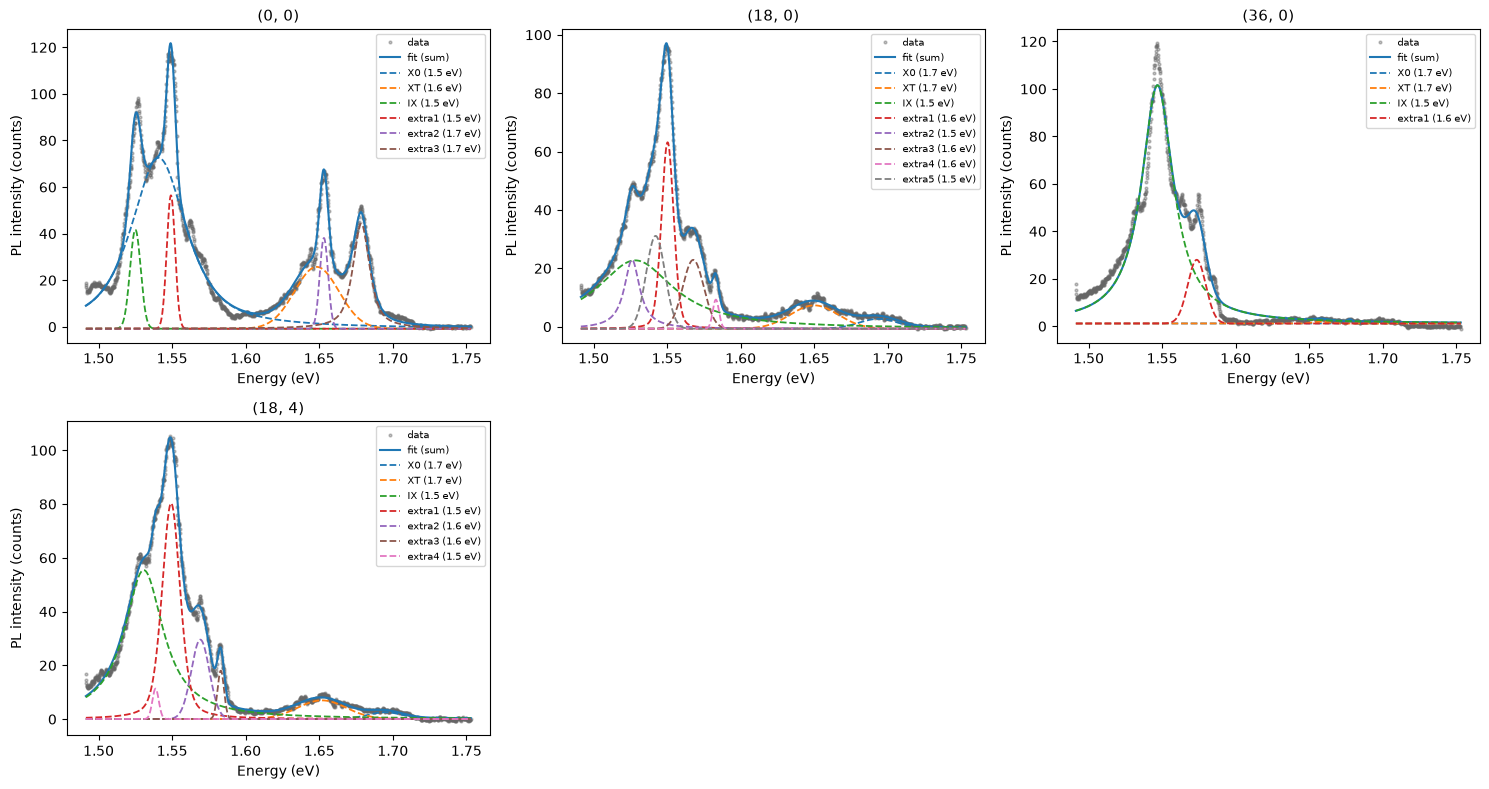

In [ ]:
FIT_WINDOW = constants.PL_PEAKS["WSe2"]["fit_window"]

fit_results, fit_windows = {}, {}
for fast_val, slow_val in points:
    label = f"({fast_val:.3g}, {slow_val:.3g})"
    spectrum = processing.smooth_savgol(scan.get_spectrum_at(fast=fast_val, slow=slow_val),
                                         window=SMOOTH_WINDOW, poly_order=SMOOTH_POLY)

    mask = (scan.energy >= FIT_WINDOW[0]) & (scan.energy <= FIT_WINDOW[1])
    fit_windows[label] = (scan.energy[mask], spectrum[mask])

    base_result = fitting.fit_pl_peaks(scan.energy, spectrum, material="WSe2")
    fit_results[label] = fitting.find_extra_peaks(*fit_windows[label], base_result)

n_named = len(constants.PL_PEAKS["WSe2"]["peaks"])
for label, result in fit_results.items():
    n_peaks = sum(1 for k in result.params if k.startswith("center_"))
    print(f"{label}: {n_peaks - n_named} additional peak(s) beyond X0/XT/IX")
    for i in range(n_peaks):
        name = (constants.PL_PEAKS["WSe2"]["peaks"][i] if i < n_named
                else f"extra{i - n_named + 1}")
        print(f"    {name:>7s}: center={result.params[f'center_{i}']:.4f} eV  "
              f"amp={result.params[f'amp_{i}']:.0f}")

# Sized to whatever find_extra_peaks actually found, not a hardcoded cap.
max_peaks = max(sum(1 for k in r.params if k.startswith("center_")) for r in fit_results.values())
mode_names = constants.PL_PEAKS["WSe2"]["peaks"] + [f"extra{i}" for i in range(1, max_peaks - n_named + 1)]

fig, axes = plotting.plot_multi_voigt_overlay(
    fit_results, fit_windows, mode_names,
    xlabel="Energy (eV)", ylabel=scan.signal_label, x_unit=" eV",
)